In [1]:
import numpy as np

rng = np.random.default_rng(2026)

a = rng.integers(0, 100, size=12)
print(a)
print(a.max(), a.min(), a.mean(), a.argmin(), a.argmax())

m = a.reshape(3, 4)
print(m.shape)
print(m)
print(m.sum(axis=1))
print(m.max(axis=0))

u = rng.standard_normal(5)
v = rng.standard_normal(5)
print(np.dot(u, v))
print(u @ v)

mat = np.arange(60).reshape(6, 10)
print(mat[2:5, 3:8])
print(mat[mat > 50][:10])


[85 17  2 63 36 46  7 37 64 35 83 79]
85 2 46.166666666666664 2 0
(3, 4)
[[85 17  2 63]
 [36 46  7 37]
 [64 35 83 79]]
[167 126 261]
[85 46 83 79]
-0.6356549053143975
-0.6356549053143975
[[23 24 25 26 27]
 [33 34 35 36 37]
 [43 44 45 46 47]]
[51 52 53 54 55 56 57 58 59]


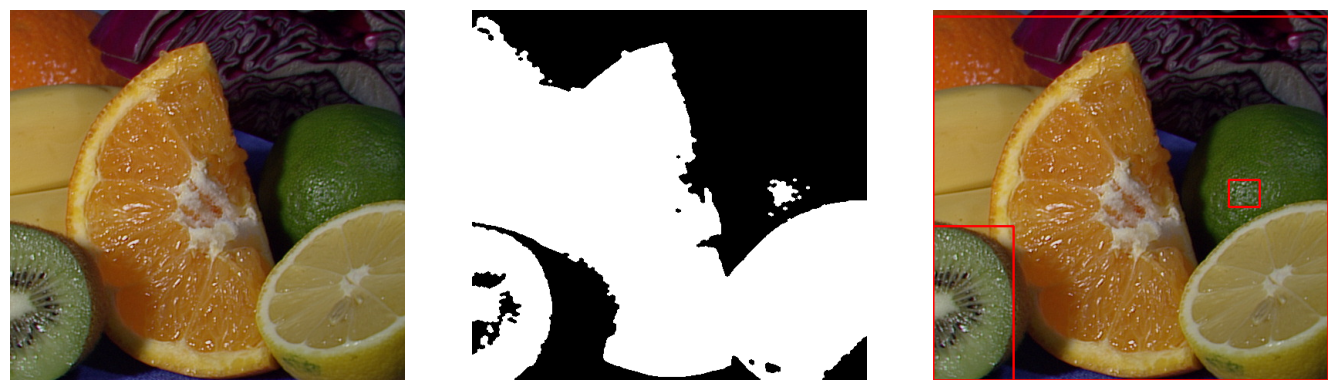

3


In [2]:
from pathlib import Path
import urllib.request

import cv2
import numpy as np
import matplotlib.pyplot as plt

FRUITS_URL = (
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/fruits.jpg"
)
img_path = Path("data/lab1_internet.jpg")
img_path.parent.mkdir(parents=True, exist_ok=True)

if not img_path.exists():
    req = urllib.request.Request(
        FRUITS_URL,
        headers={"User-Agent": "ITMO-CV-lab1/1.0 (educational)"},
    )
    with urllib.request.urlopen(req, timeout=30) as resp:
        img_path.write_bytes(resp.read())

bgr = cv2.imread(str(img_path))
assert bgr is not None
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

_, thr = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
bg_brightness = gray.mean()
if bg_brightness > 127:
    thr = cv2.bitwise_not(thr)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
thr = cv2.morphologyEx(thr, cv2.MORPH_OPEN, kernel)
thr = cv2.morphologyEx(thr, cv2.MORPH_CLOSE, kernel)

contours, _ = cv2.findContours(thr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

vis_bgr = bgr.copy()
min_area = (rgb.shape[0] * rgb.shape[1]) * 0.002
boxes = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < min_area:
        continue
    x, y, w, h = cv2.boundingRect(cnt)
    boxes.append((x, y, w, h))
    cv2.rectangle(vis_bgr, (x, y), (x + w, y + h), (0, 0, 255), 2)

vis_cv = cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(rgb)
axes[1].imshow(thr, cmap="gray")
axes[2].imshow(vis_cv)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(len(boxes))


In [3]:
def numpy_rectangle_rgb(
    img_rgb: np.ndarray,
    pt1: tuple[int, int],
    pt2: tuple[int, int],
    color: tuple[float, float, float] | tuple[int, int, int],
    line_width: int = 2,
) -> np.ndarray:
    out = np.array(img_rgb, copy=True, dtype=img_rgb.dtype, order="C")
    if out.ndim != 3 or out.shape[2] != 3:
        raise ValueError

    h, w = out.shape[:2]
    x1, y1 = int(pt1[0]), int(pt1[1])
    x2, y2 = int(pt2[0]), int(pt2[1])
    xa, xb = sorted((x1, x2))
    ya, yb = sorted((y1, y2))
    lw = max(1, int(line_width))

    xa = max(0, min(w - 1, xa))
    xb = max(0, min(w - 1, xb))
    ya = max(0, min(h - 1, ya))
    yb = max(0, min(h - 1, yb))

    if xb <= xa or yb <= ya:
        return out

    col = np.asarray(color, dtype=out.dtype)
    if col.shape != (3,):
        raise ValueError

    y_top_end = min(ya + lw, h)
    y_bot_start = max(0, yb - lw + 1)
    out[ya:y_top_end, xa : xb + 1] = col
    out[y_bot_start : yb + 1, xa : xb + 1] = col
    x_left_end = min(xa + lw, w)
    x_right_start = max(0, xb - lw + 1)
    out[ya : yb + 1, xa:x_left_end] = col
    out[ya : yb + 1, x_right_start : xb + 1] = col
    return out


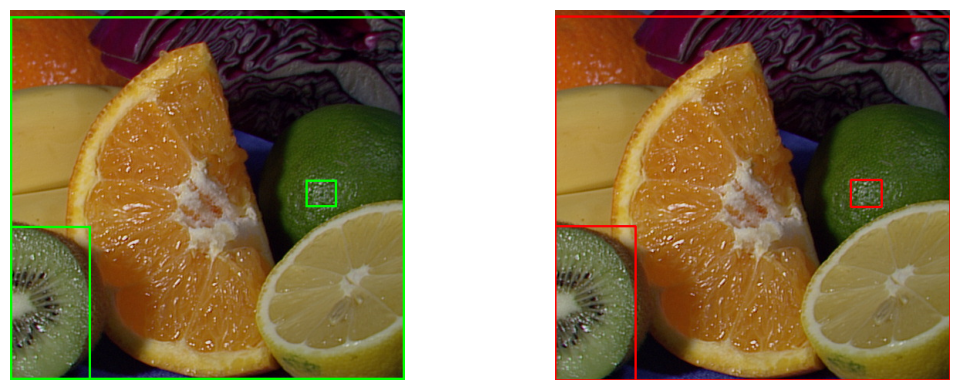

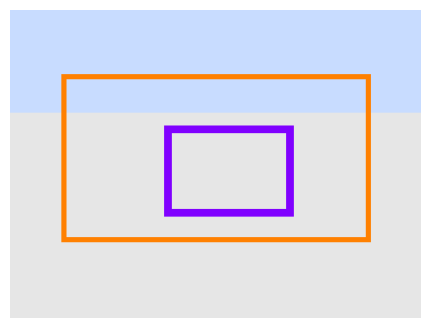

In [4]:
vis_np = rgb.copy()
GREEN = (0, 255, 0)
for (x, y, bw, bh) in boxes:
    vis_np = numpy_rectangle_rgb(vis_np, (x, y), (x + bw, y + bh), GREEN, line_width=3)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(vis_np)
ax[1].imshow(vis_cv)
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

canvas = np.full((240, 320, 3), 230, dtype=np.uint8)
canvas[:80, :] = (200, 220, 255)
canvas = numpy_rectangle_rgb(canvas, (40, 50), (280, 180), (255, 128, 0), line_width=4)
canvas = numpy_rectangle_rgb(canvas, (120, 90), (220, 160), (128, 0, 255), line_width=6)

plt.figure(figsize=(6, 4))
plt.imshow(canvas)
plt.axis("off")
plt.show()
